# Teste de treinamento de modelo para predição de Resistência utilizando CatBoost

In [3]:
%%capture
!pip install catboost ipywidgets optuna

In [4]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GroupKFold
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

### Montagem do drive

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
filename = 'df_resistencia_sem_feature_engineering.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Resistencia_Compressao_MPa'].copy()
df.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 572 entries, 15 to 598
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Autores/ano                  572 non-null    object 
 1   Massa_Esp_Cimento_g_cm3      435 non-null    float64
 2   Finura_Cimento_Blaine_m2_kg  572 non-null    float64
 3   Massa_Esp_Filer_g_cm3        346 non-null    float64
 4   Massa_Esp_Areia_g_cm3        235 non-null    float64
 5   Massa_Esp_Brita_g_cm3        246 non-null    float64
 6   Cimento_kg_m3                572 non-null    float64
 7   Filer_Calcario_kg_m3         572 non-null    float64
 8   Agua_kg_m3                   572 non-null    float64
 9   Agregado_Miudo_Total_kg_m3   572 non-null    float64
 10  Agregado_Graudo_Total_kg_m3  572 non-null    float64
 11  Superplastificante_kg_m3     527 non-null    float64
 12  Relacao_Agua_Cimento         572 non-null    float64
 13  idade                   

In [7]:
n_groups = df['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 17


In [18]:
%%time
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

def objective(trial):

    rmse_scores = []
    hyper_params = {
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': 42,
        'iterations': trial.suggest_int('iterations', 100, 400),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.05, log=True
        ),
        'depth': trial.suggest_int('depth', 1, 8),
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 0, 100
        ),
        'min_data_in_leaf': trial.suggest_int(
            'min_data_in_leaf', 1, 30
        ),
        'random_strength': trial.suggest_float(
            'random_strength', 0, 10
        ),
        'bagging_temperature': trial.suggest_float(
            'bagging_temperature', 0, 10
        ),
        'od_type': 'Iter',
        'od_wait': trial.suggest_int(
            'od_wait', 10, 300
        ),
        'task_type': 'GPU',
        'devices': '0'
    }

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = CatBoostRegressor(**hyper_params)

        model.fit(
            X_train,
            y_train,
            verbose=False
        )

        preds = model.predict(X_val)

        rmse_scores.append(
            root_mean_squared_error(y_val, preds)
        )

    return np.mean(rmse_scores)

CPU times: user 1.39 ms, sys: 0 ns, total: 1.39 ms
Wall time: 1.28 ms


# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 150

pbar = tqdm(total=n_trials, desc="Otimizando")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]   
)

pbar.close()

print("\n" + "="*50)
print("🏆 OTIMIZAÇÃO CONCLUÍDA")
print("="*50)
print(f"Melhor RMSE alcançado (Cross-Validation): {study.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"  '{key}': {value},")

In [20]:
best_params = {'iterations': 253,
               'learning_rate': 0.023443685685881472,
               'depth': 4,
               'l2_leaf_reg': 0.07708612528045933,
               'min_data_in_leaf': 12,
               'random_strength': 5.111803708453416,
               'bagging_temperature': 6.521777013368886,
               'od_wait': 292}


In [21]:
best_params.update({
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'task_type': 'GPU',
    'devices': '0'
})

In [22]:
%%time
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

all_preds = []
all_true = []
all_groups = []
rmse_scores = []

results = []
importancias_cat = []

train_curves = []
val_curves = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(**best_params)

    model.fit(
        X_train,
        y_train,
        verbose=False
    )

    # CURVAS DE APRENDIZADO (RMSE calculado manualmente)
    train_curve = [
        root_mean_squared_error(y_train, pred)
        for pred in model.staged_predict(X_train)
    ]

    val_curve = [
        root_mean_squared_error(y_val, pred)
        for pred in model.staged_predict(X_val)
    ]

    train_curves.append(train_curve)
    val_curves.append(val_curve)

    preds = model.predict(X_val)

    all_preds.extend(preds)

    all_true.extend(y_val)

    rmse_scores.append(
        root_mean_squared_error(y_val, preds)
    )

    all_groups.extend(groups.iloc[val_idx])

    importancias_cat.append(
        model.feature_importances_
    )

CPU times: user 48.5 s, sys: 6.84 s, total: 55.4 s
Wall time: 37.1 s


In [23]:
print(best_params)

{'iterations': 253, 'learning_rate': 0.023443685685881472, 'depth': 4, 'l2_leaf_reg': 0.07708612528045933, 'min_data_in_leaf': 12, 'random_strength': 5.111803708453416, 'bagging_temperature': 6.521777013368886, 'od_wait': 292, 'loss_function': 'RMSE', 'eval_metric': 'RMSE', 'random_seed': 42, 'od_type': 'Iter', 'task_type': 'GPU', 'devices': '0'}


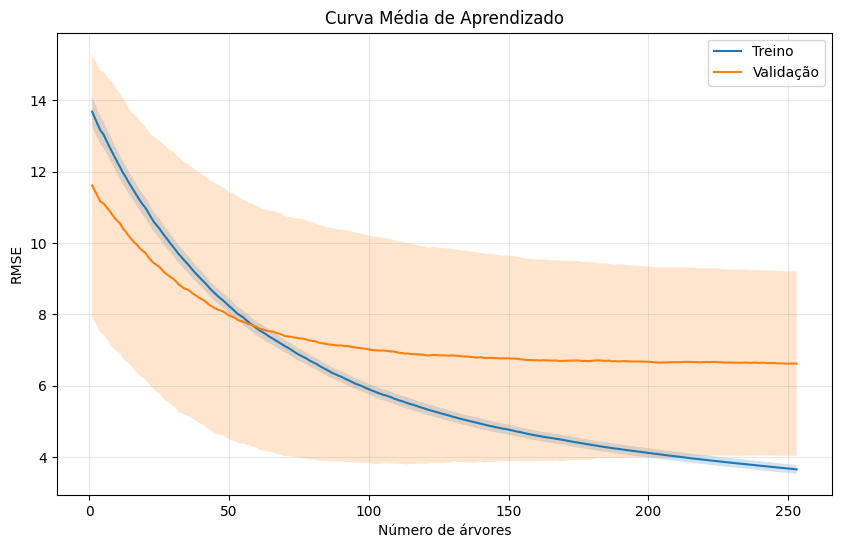

In [24]:
max_len = max(
    max(len(c) for c in train_curves),
    max(len(c) for c in val_curves)
)

train_matrix = np.full(
    (len(train_curves), max_len),
    np.nan
)

val_matrix = np.full(
    (len(val_curves), max_len),
    np.nan
)

for i, curve in enumerate(train_curves):
    train_matrix[i, :len(curve)] = curve

for i, curve in enumerate(val_curves):
    val_matrix[i, :len(curve)] = curve

train_mean = np.nanmean(train_matrix, axis=0)
train_std = np.nanstd(train_matrix, axis=0)

val_mean = np.nanmean(val_matrix, axis=0)
val_std = np.nanstd(val_matrix, axis=0)

iterations = np.arange(1, max_len + 1)

plt.figure(figsize=(10, 6))

plt.plot(iterations, train_mean, label='Treino')
plt.plot(iterations, val_mean, label='Validação')

plt.fill_between(
    iterations,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    iterations,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel('Número de árvores')
plt.ylabel('RMSE')
plt.title('Curva Média de Aprendizado')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [25]:
# Resumo das curvas de aprendizado por fold
train_final = np.mean([curve[-1] for curve in train_curves if len(curve)])
val_final = np.mean([curve[-1] for curve in val_curves if len(curve)])
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 RESUMO DAS CURVAS DE APRENDIZADO")
print("="*60)
print("Métrica: último ponto disponível de cada fold")
print(f"✅ RMSE Treino (final por fold):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final por fold):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):                 {overfitting_gap:.6f}")
print("="*60)


📊 RESUMO DAS CURVAS DE APRENDIZADO
Métrica: último ponto disponível de cada fold
✅ RMSE Treino (final por fold):      3.657407
⚠️  RMSE Validação (final por fold):   6.619200
📈 Gap (Val - Train):                 2.961793


In [26]:
debug_df = pd.DataFrame({
    'y_true': np.array(all_true),
    'y_pred': np.array(all_preds),
    'group': np.array(all_groups)
})

debug_df['residual'] = (
    debug_df['y_true'] - debug_df['y_pred']

)

debug_df["abs_error"] = (
    debug_df["residual"].abs()
)

In [27]:
oof_rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])

print("\n" + "="*60)
print("📌 COMPARAÇÃO CONSISTENTE DE MÉTRICAS")
print("="*60)
print(f"✅ RMSE OOF (todas as previsões fora da amostra): {oof_rmse:.6f}")
print("="*60)


📌 COMPARAÇÃO CONSISTENTE DE MÉTRICAS
✅ RMSE OOF (todas as previsões fora da amostra): 8.200115


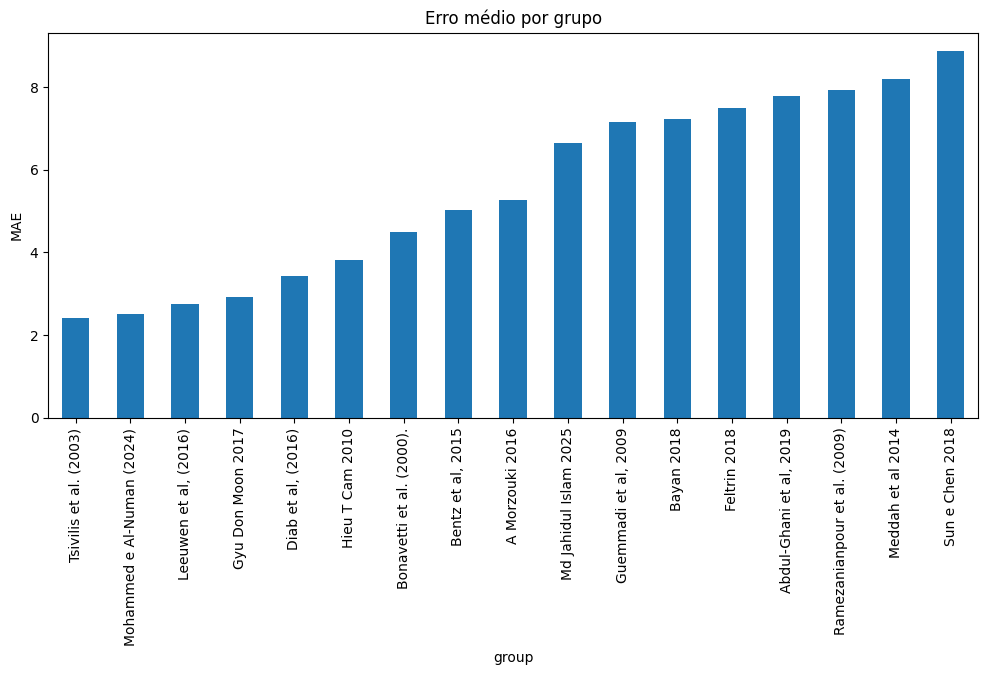

In [28]:
group_errors = (
    debug_df
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

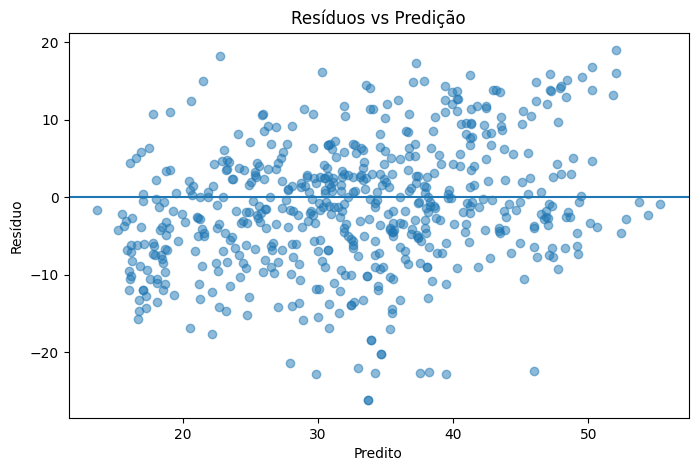

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(
    debug_df["y_pred"],
    debug_df["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

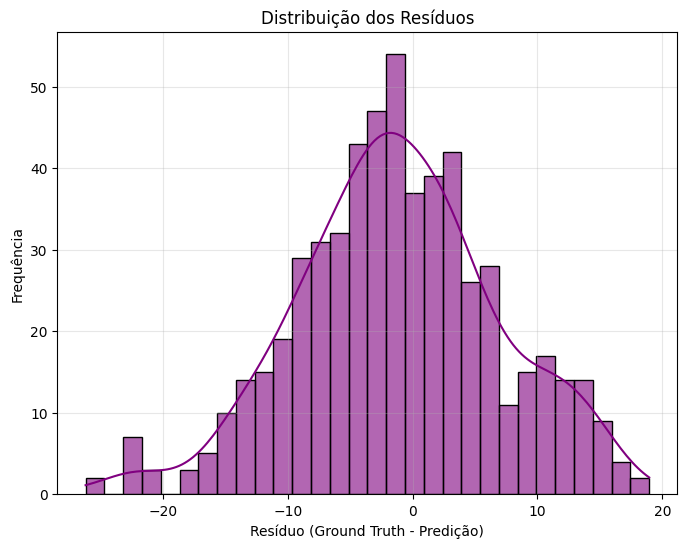

In [30]:
plt.figure(figsize=(8, 6))

sns.histplot(
    debug_df['residual'],
    bins=30,
    kde=True,
    color='purple',
    alpha=0.6
)

plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")

plt.grid(True, alpha=0.3)

plt.show()

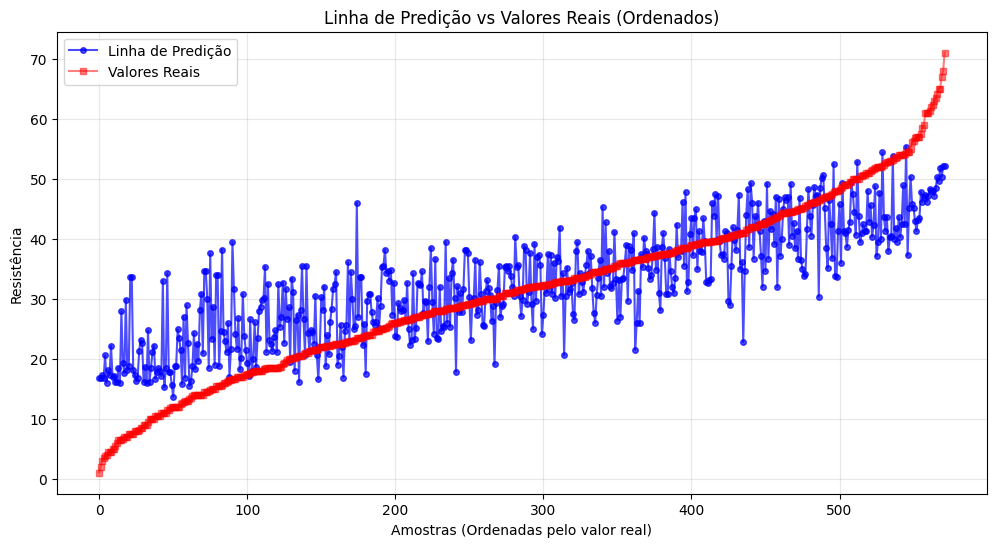

In [31]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição",
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais",
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 8.2001
mean_absolute_error: 6.4653
mean_absolute_percentage_error: 0.3826
R² Score: 65.2499


In [33]:
model = CatBoostRegressor(**study.best_params)
model.fit(X, y, verbose=False)

CatBoostRegressor(bagging_temperature=6.521777013368886, depth=4, iterations=253, l2_leaf_reg=0.07708612528045933, learning_rate=0.023443685685881472, loss_function='RMSE', min_data_in_leaf=12, od_wait=292, random_strength=5.111803708453416)

/tmp/ipykernel_629/3575547520.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')


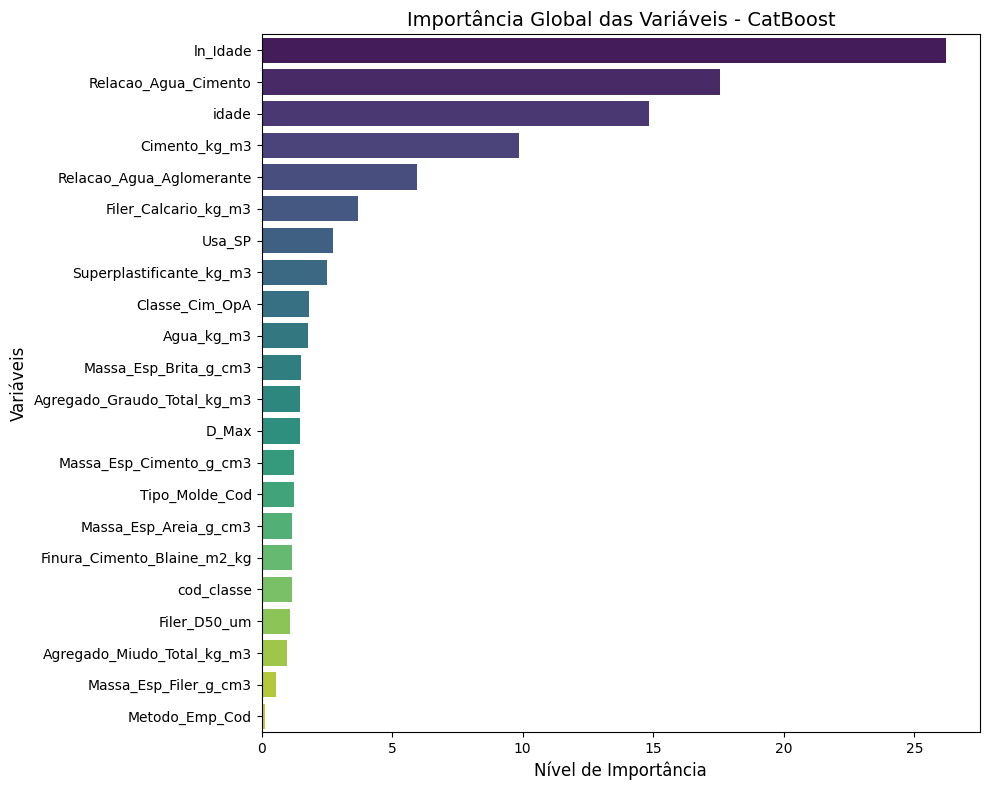

In [34]:
importancias = model.get_feature_importance()
features = X.columns

df_importancia = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')
plt.title('Importância Global das Variáveis - CatBoost', fontsize=14)
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.tight_layout()
plt.show()